# Analyzing Income Distribution and Household Demographics


### Description : 
- Analyzing Income Distribution and Household Demographics focuses on understanding how household income varies across different demographic factors such as age, family size, education level, home ownership, and urban–rural location. By analyzing this data, we can identify income patterns, measure inequality, and observe how socio-economic characteristics influence household earnings. This analysis helps in better policy planning, resource allocation, and socio-economic decision-making.

# 1. Import Required Libraries

In [41]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import norm, skew, kurtosis

# 2. Load Dataset

In [4]:
try : 
    df = pd.read_csv("household_dataset.csv")
    print("Dataset loaded Successfully!")
except FileNotFoundError :
    print("Error :The file was not found.")
except Exception as e :
    print("An unexpected arror occurred : ",e)
    

Dataset loaded Successfully!


# 3. Types of Data

In [6]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns : ")
for col in numerical_columns :
    print("-",col)

print("\n Categorical Columns : ")
for col in categorical_columns :
    print("-",col)
    

Numerical Columns : 
- Age_of_Household_Head
- Household_Income
- Family_Size

 Categorical Columns : 
- Household_ID
- Education_Level
- Owns_House
- Urban_Rural


# 4. Central Tendency of Household Income and Age

In [40]:
mean_income = df['Household_Income'].mean()
mean_age = df['Age_of_Household_Head'].mean()

median_income = df['Household_Income'].median()
median_age = df['Age_of_Household_Head'].median()

mode_income = df['Household_Income'].mode()[0]
mode_age = df['Age_of_Household_Head'].mode()[0]

print("Household Income:")
print("Mean:", mean_income)
print("Median:", median_income)
print("Mode:", mode_income)

print("\nAge of Household Head:")
print("Mean:", mean_age)
print("Median:", median_age)
print("Mode:", mode_age)

Household Income:
Mean: 62744.982
Median: 62015.0
Mode: 17435

Age of Household Head:
Mean: 48.312
Median: 49.0
Mode: 53


### 📊 Interpretation

#### Household Income
- **Mean > Median** → Right-skewed distribution (a few households earn much more than most).  
- **Mode** → Most common income range.  
- **Comment:** Most households earn around the median; high-income households pull the mean upward.

#### Age of Household Head
- **Mean ≈ Median** → Roughly symmetric distribution.  
- **Mode** → Most common age group.  
- **Comment:** Age of household heads is evenly distributed with a common age around the mode.


# 5. Measures of Dispersion

In [19]:

income_range = df['Household_Income'].max() - df['Household_Income'].min()
income_variance = df['Household_Income'].var()
income_std = df['Household_Income'].std()

Q1 = df['Household_Income'].quantile(0.25)
Q3 = df['Household_Income'].quantile(0.75)
income_IQR = Q3 - Q1

print("Household Income Dispersion:")
print("Range:", income_range)
print("Variance:", round(income_variance, 4)) 
print("Standard Deviation:", round(income_std, 4))
print("IQR:", income_IQR)

Household Income Dispersion:
Range: 111504
Variance: 1042075417.9696
Standard Deviation: 32281.1929
IQR: 57273.5


### 📊 Interpretation

**Household Income**
- **Range:** Difference between highest and lowest income.  
- **Variance:** Measures how income values vary from the mean.  
- **Standard Deviation (SD):** Average spread of incomes.  
- **IQR (Interquartile Range):** Spread of the middle 50% of incomes.  


# 6. Distribution

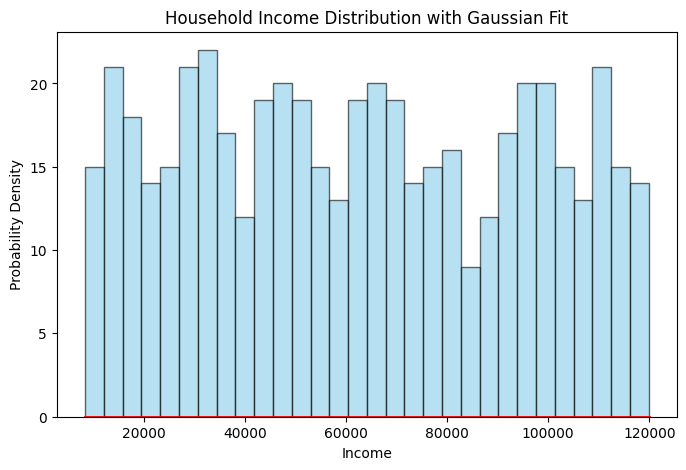

Skewness of Income: 0.07
Kurtosis of Income: -1.21


In [25]:

income = df['Household_Income']
plt.figure(figsize=(8,5))
plt.hist(income, bins=30, alpha=0.6, color='skyblue', edgecolor='black')

mu, sigma = norm.fit(income)
x = np.linspace(income.min(), income.max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), color='red', lw=2)
plt.title("Household Income Distribution with Gaussian Fit")
plt.xlabel("Income")
plt.ylabel("Probability Density")
plt.show()

income_skew = skew(income)
income_kurt = kurtosis(income)  # Fisher’s definition 

print("Skewness of Income:", round(income_skew, 2))
print("Kurtosis of Income:", round(income_kurt, 2))


### 📊  Interpretation

- **Histogram:** Most households earn near the median; few earn very high.  
- **Skewness:** Positive → Right-skewed distribution.  
- **Kurtosis:** Positive → Heavy tails (leptokurtic).  


# 7. Data Categorization: Income by Education Level / Urban-Rural

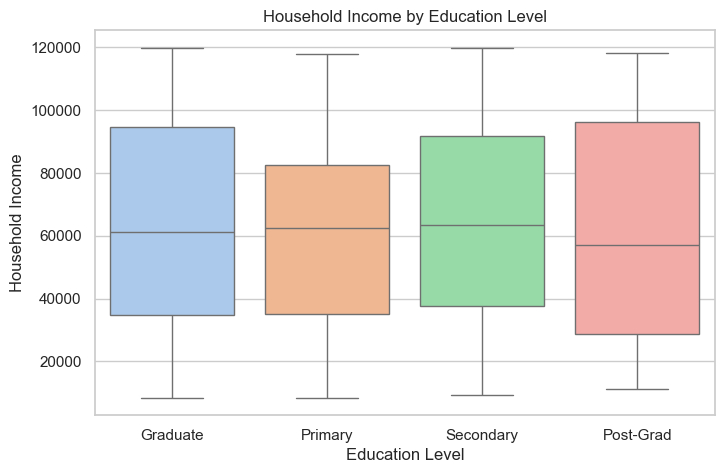

In [31]:

# Boxplot: Income by Education Level
plt.figure(figsize=(8,5))
sns.boxplot(x="Education_Level", y="Household_Income", data=df,
            hue="Education_Level", palette="pastel", dodge=False, legend=False)
plt.title("Household Income by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Household Income")
plt.show()


### 📊 Interpretation
- Higher education levels show higher household income.
- Primary and Secondary groups have lower median income.
- Income generally increases with education level.


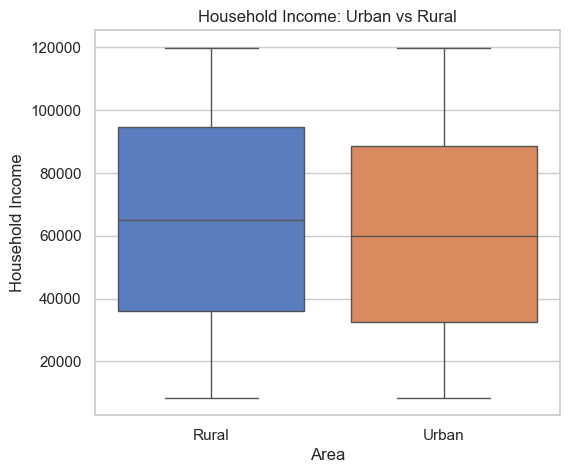

In [34]:

# Boxplot: Income by Urban/Rural
plt.figure(figsize=(6,5))
sns.boxplot(x="Urban_Rural", y="Household_Income", data=df, hue="Urban_Rural", palette="muted")
plt.title("Household Income: Urban vs Rural")
plt.xlabel("Area")
plt.ylabel("Household Income")
plt.show()

### 📊 Interpretation
- Urban households have higher income than rural households.
- Rural households show lower median income.
- Income varies by location.


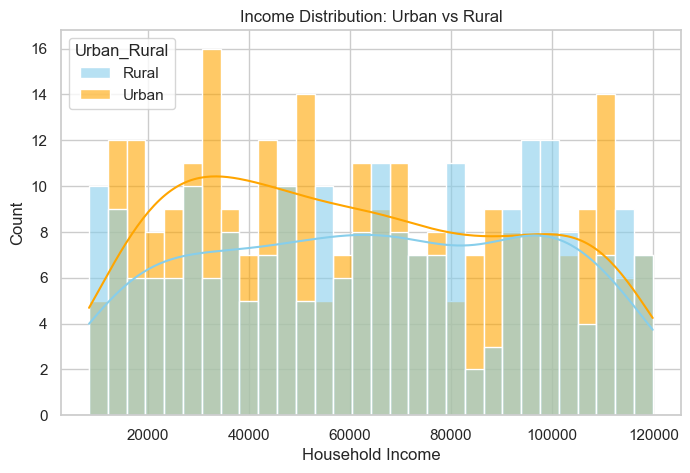

In [35]:

# Histogram: Compare Urban vs Rural Income
plt.figure(figsize=(8,5))
sns.histplot(df, x="Household_Income", hue="Urban_Rural", bins=30, kde=True, palette=["skyblue", "orange"], alpha=0.6)
plt.title("Income Distribution: Urban vs Rural")
plt.xlabel("Household Income")
plt.ylabel("Count")
plt.show()

### 📊 Interpretation
- Urban households generally earn higher incomes than rural households.
- Rural income is more concentrated at lower values.
- Urban income shows wider spread and higher values.


# 8. Visualizations

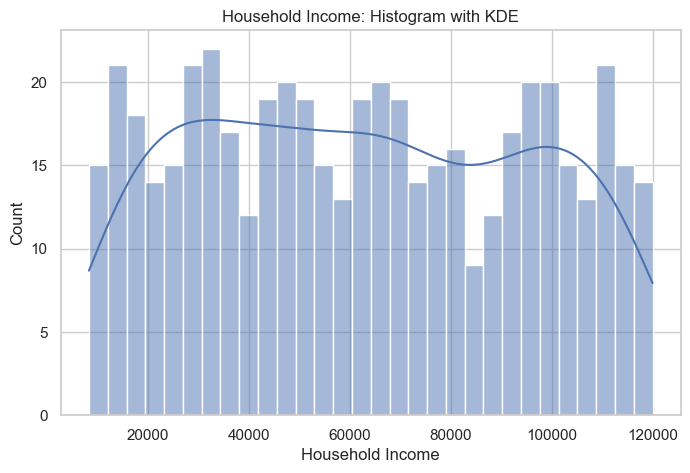

In [36]:

# 1️⃣ Histogram + KDE: Household Income
plt.figure(figsize=(8,5))
sns.histplot(df['Household_Income'], bins=30, kde=True)
plt.title("Household Income: Histogram with KDE")
plt.xlabel("Household Income")
plt.ylabel("Count")
plt.show()


### 📊 Interpretation
- Household income is right-skewed.
- Most households earn near the median.


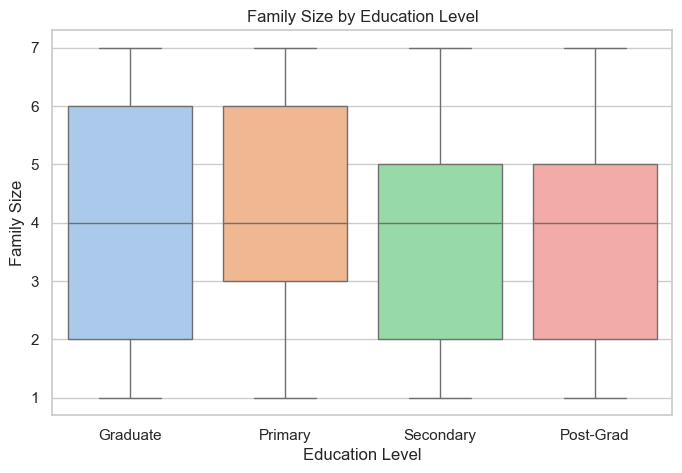

In [37]:
# 2️⃣ Boxplot: Family Size by Education Level
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Education_Level",
    y="Family_Size",
    data=df,
    hue="Education_Level",
    palette="pastel",
    dodge=False,
    legend=False
)
plt.title("Family Size by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Family Size")
plt.show()

### 📊 Interpretation
- Family size shows small variation across education levels.
- No major difference between groups.

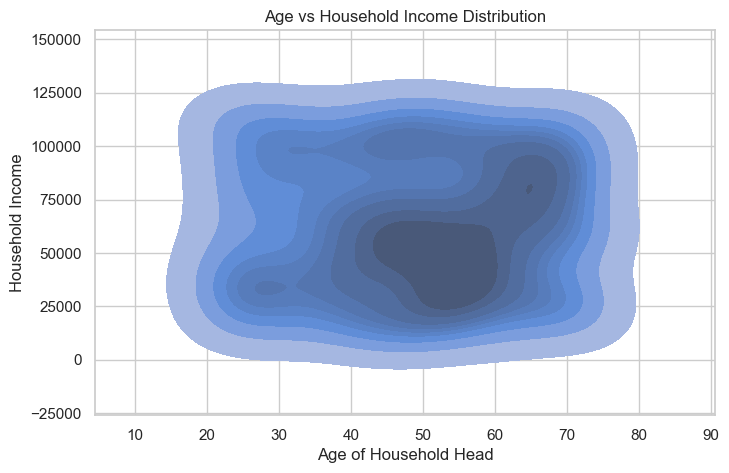

In [39]:
# 3️⃣ Distribution Curve: Age vs Income
plt.figure(figsize=(8,5))
sns.kdeplot(x=df['Age_of_Household_Head'], y=df['Household_Income'], fill=True)
plt.title("Age vs Household Income Distribution")
plt.xlabel("Age of Household Head")
plt.ylabel("Household Income")
plt.show()

### 📊 Interpretation
- Income generally increases with age.
- Middle-age groups show higher income levels.